# TMRM Distribution Patterns and Heterogeneity

In [23]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot
import numpy as np

## Change the global variable to get the dashboard

In [24]:
# Global variables - CHANGE THESE
feature = "Mitochondria Intensity - Nucleus region Mean"
secondary_feature = "Mitochondria Intensity - Nucleus region CV [%]"
category = "Cellline ID"
data_path = 'data/Raw_Data_Batch1_LAB2_CTX2.csv'
######

## Automate the Dashboard Creation

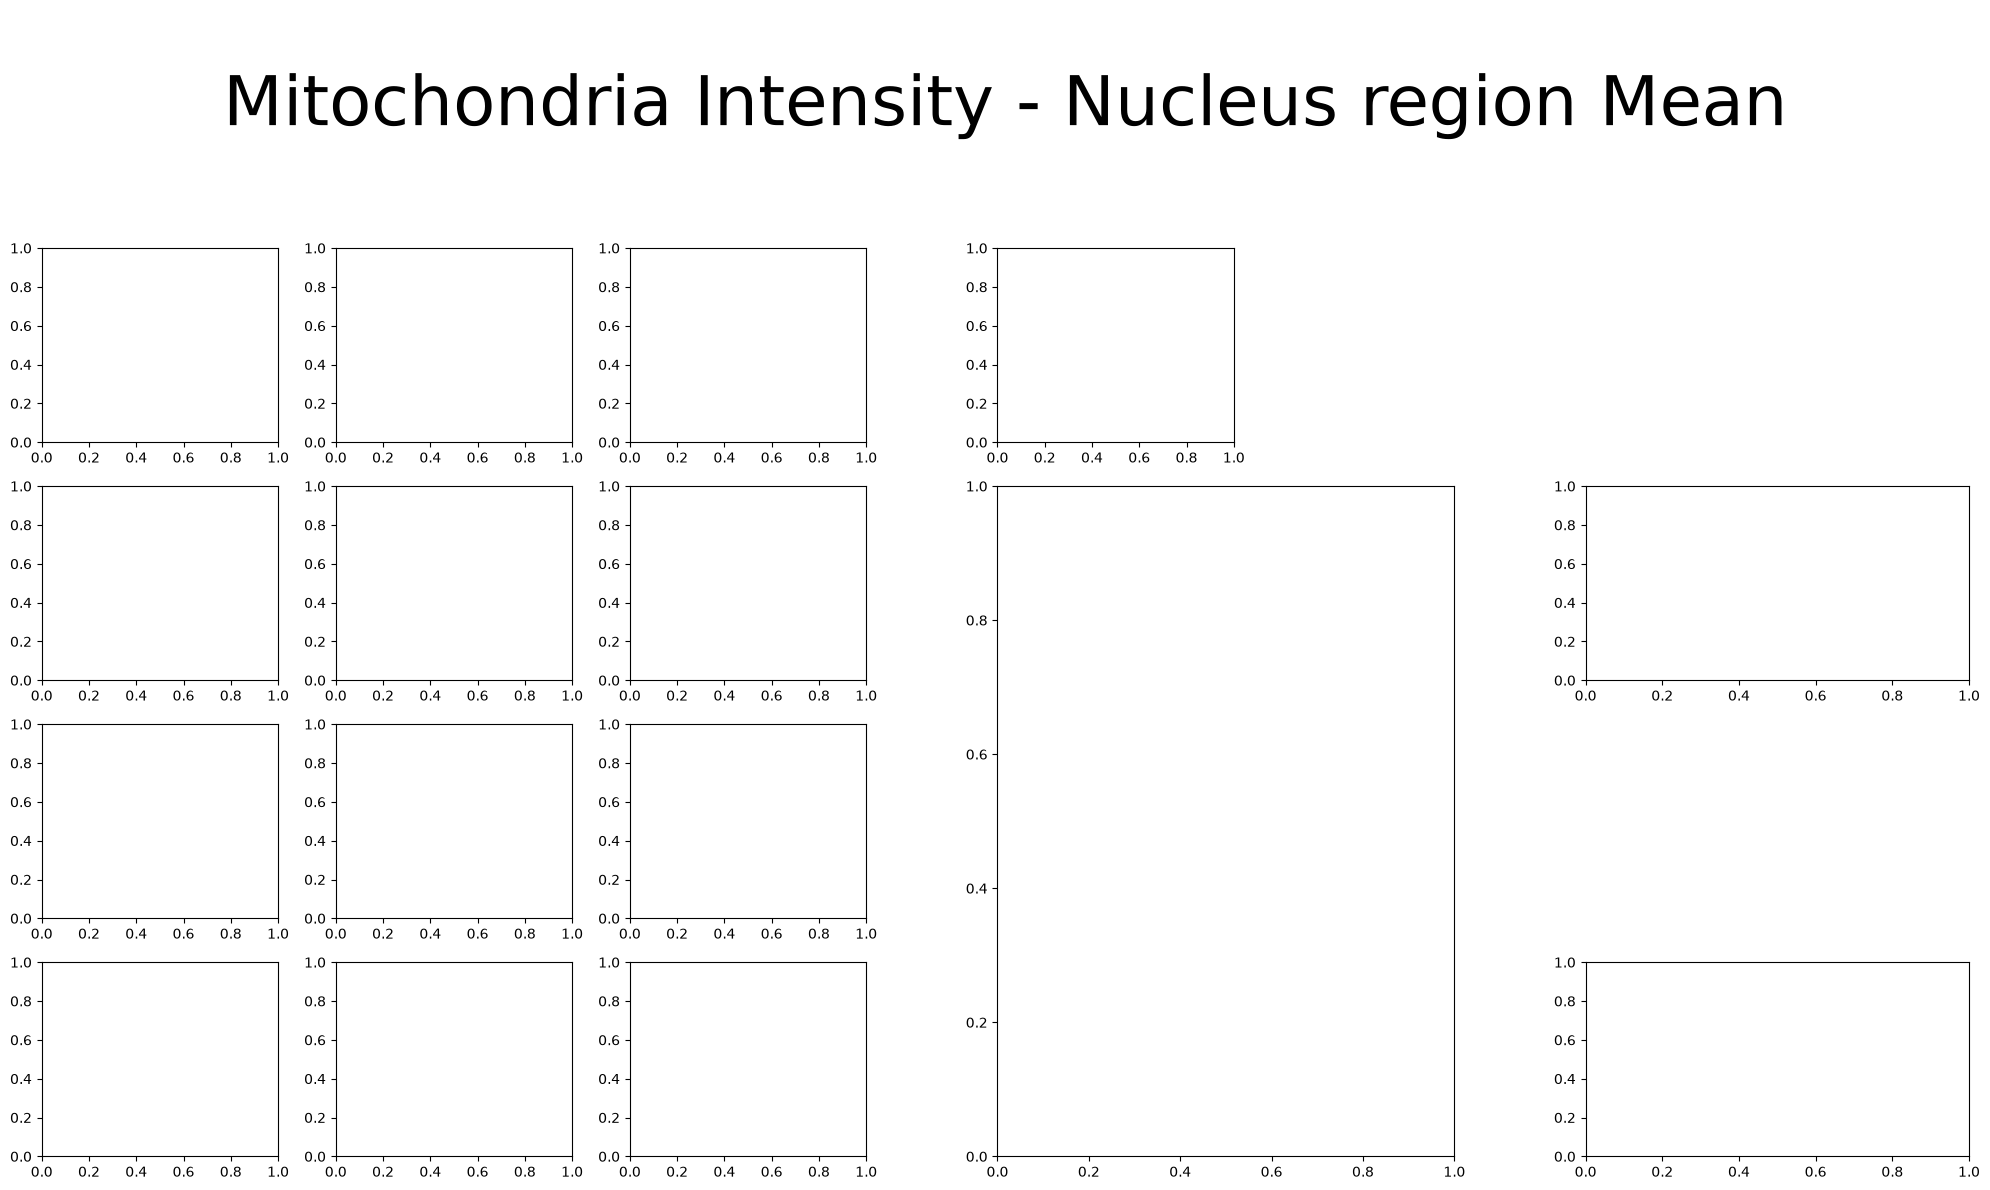

In [25]:
# # 1. Define complex layout using text characters.
# # Each letter represents a distinct plot area. 
# # Repeating a letter makes that plot span multiple rows/columns.

layout = """
    000000000000000000000000000
    LLLLEEEEHHHHVIIIITTTTTTTTTT
    QQQQRRRRSSSSVAAAAAAAZBBBBBB
    KKKKCCCCFFFFVAAAAAAAZ999999
    JJJJDDDDGGGGVAAAAAAAZ222222
"""

fig, axes = pyplot.subplot_mosaic(layout, figsize=(20, 12))

# # 2. Add text title to the top left (Area '0')
axes['0'].axis('off') # Hide grid lines
axes['0'].text(0.5, 0.5, feature, 
               fontsize=50, ha='center', va='center')
axes['Z'].axis('off') # Hide grid lines
axes['V'].axis('off') # Hide grid lines
axes['9'].axis('off') # Hide grid lines

# 3. Assign Seaborn plots to specific axes
# sns.histplot(data=df, x='...', ax=axes['A']) 
# sns.boxplot(data=df, x='...', y='...', ax=axes['B'])

# Example: The grid of small histograms (Areas L, E, H, I, Q, R, etc.)
# sns.histplot(..., ax=axes['B'])

# 4. Add Pandas DataFrame as a table (Area 'T')
axes['T'].axis('tight')
axes['T'].axis('off')

# table = axes['T'].table(cellText=summary_df.values,
#                         colLabels=summary_df.columns,
#                         loc='center',
#                         cellLoc='center')
# table.scale(1, 1.5) # Adjust table sizing

pyplot.tight_layout()

def identify_axes(ax_dict, fontsize=48):
    """
    Helper to identify the Axes in the examples below.

    Draws the label in a large font in the center of the Axes.

    Parameters
    ----------
    ax_dict : dict[str, Axes]
        Mapping between the title / label and the Axes.
    fontsize : int, optional
        How big the label should be.
    """
    kw = dict(ha="center", va="center", fontsize=fontsize, color="darkgrey")
    for k, ax in ax_dict.items():
        ax.text(0.5, 0.5, k, transform=ax.transAxes, **kw)


# ax_dict = fig.subplot_mosaic(layout)
# identify_axes(ax_dict)

# Functions

### Function to calculate the P1, P5, P95 and P99

In [26]:
def calculate_percentiles(df, percentile_metric, feature_name):
    percentile_value = 1
    if percentile_metric == 'P5':
        percentile_value = 5
    elif percentile_metric == 'P25':
        percentile_value = 25
    elif percentile_metric == 'P50':
        percentile_value = 50
    elif percentile_metric == 'P75':
        percentile_value = 75
    elif percentile_metric == 'P95':
        percentile_value = 95
    elif percentile_metric == 'P99':
        percentile_value = 99
    else:
        percentile_value = 80
    
    percentile = np.percentile(df[[feature_name]],
                               percentile_value)
    
    return percentile

### Function to create a density plot given the dataframe and the feature

In [27]:
def create_density_plot(df, feature_name, category):

    selected_cols_df = df[[feature_name, category]]

    # Only the get the values that are lower than P99 
    # to remove outliers
    P95 = calculate_percentiles(selected_cols_df,
                                'P95',
                                feature_name)

    selected_cols_df  = selected_cols_df[selected_cols_df[feature_name] < P95]

    density_plot = sns.kdeplot(data=selected_cols_df,
                 x=feature_name, 
                 hue=category, 
                 common_norm=False,
                 fill=True)
    density_plot.set_title(feature_name)


    return density_plot

In [28]:
def create_hist_plot(df, feature_name, category, fill_colour):
    global axes
    # sns.histplot(data=df, x='...', ax=axes['E']) 
    selected_cols_df = df[[feature_name, category]]

    # Only the get the values that are lower than P99 
    # to remove outliers
    P95 = calculate_percentiles(selected_cols_df,
                                'P95',
                                feature_name)

    selected_cols_df  = selected_cols_df[selected_cols_df[feature_name] < P95]

    hist_plot = sns.histplot(data=selected_cols_df,
                 x=feature_name, 
                 hue=category,
                 stat="percent",
                 common_norm=False,
                 element="step",
                 fill=True,
                 ax=axes['A'])
    
    
    
    hist_plot.set_xlim(0, P95 + 100)
        # hist_plot = create_hist_plot(select_rows, feature_name, category, fill_colour)

    hist_plot.set_ylim(0, 20)
        # hist_plot = create_hist_plot(select_rows, feature_name, category, fill_colour)
    
    if fill_colour != None:
        hist_plot = sns.histplot(data=selected_cols_df,
                 x=feature_name, 
                 stat="percent",
                 common_norm=False,
                 element="step",
                 color=fill_colour,
                 fill=True)
        hist_plot.set_xlim(0, P95 + 100)
    return hist_plot

### Function to create a box plot given the dataframe and the feature

In [29]:
def create_cat_plot(df, feature_name, category):
    global axes
    global feature

    selected_cols_df = df[[feature_name, category]]

    # Only the get the values that are lower than P99 
    # to remove outliers
    P95 = calculate_percentiles(selected_cols_df,
                                'P95',
                                feature_name)

    selected_cols_df  = selected_cols_df[selected_cols_df[feature_name] < P95]
    control_cols = selected_cols_df[selected_cols_df[category] == 'Control']
    control_stats = control_cols.describe()
    control_median = control_stats.loc['50%', feature_name]
    boxplot = None
    custom_palette = {
        "Control": "#a8cdd9", # Light blue
        "LRRK2": "#e28725",   # Orange
        "PRKN": "#a3e49b",    # Light green
        "SNCA": "#e12827"     # Red
    }
    # WARNING
    if feature_name == secondary_feature:
        boxplot = sns.boxplot(
                    data=selected_cols_df,
                    x=feature_name,
                    y="Cell Type",
                    palette=custom_palette,
                    order=["Control", "LRRK2", "PRKN", "SNCA"],
                    linewidth=1.2,
                    fliersize=5,
                    flierprops={"marker": "d", "markerfacecolor": "#555555", "markeredgecolor": "#555555"},
                    ax=axes["2"]
                )
        # boxplot = sns.catplot(data=selected_cols_df, x=feature_name, y="Cell Type", kind="box", hue=category, palette=["lightblue", "darkorange", "lightgreen", "red"], ax=axes['2'])
    elif feature_name == feature:
        # boxplot = sns.catplot(data=selected_cols_df, x=feature_name, y="Cell Type", kind="box", hue=category, palette=["lightblue", "darkorange", "lightgreen", "red"], ax=axes['B'])
        boxplot = sns.boxplot(
                    data=selected_cols_df,
                    x=feature_name,
                    y="Cell Type",
                    palette=custom_palette,
                    order=["Control", "LRRK2", "PRKN", "SNCA"],
                    linewidth=1.2,
                    fliersize=5,
                    flierprops={"marker": "d", "markerfacecolor": "#555555", "markeredgecolor": "#555555"},
                    ax=axes["B"]
                )
    else:
        boxplot = sns.boxplot(
                    data=selected_cols_df,
                    x=feature_name,
                    y="Cell Type",
                    palette=custom_palette,
                    order=["Control", "LRRK2", "PRKN", "SNCA"],
                    linewidth=1.2,
                    fliersize=5,
                    flierprops={"marker": "d", "markerfacecolor": "#555555", "markeredgecolor": "#555555"}
                )
        
    boxplot.axvline(
        x=control_median,
        linewidth=1,
        ls='dotted',
        color='blue'
    )

    boxplot.text(x=control_median + 0.5, 
                        y=0.9, 
                        s=f"Median: {control_median:.1f}", 
                        color='blue', 
                        rotation=0,
                        transform=boxplot.get_xaxis_transform())
    
    # boxplot.fig.suptitle(feature_name)
    return boxplot

In [30]:
main_df = pd.read_csv(data_path)
mitochondria_df = main_df[[ 
                           feature,
                           secondary_feature,
                           'Cellline ID',
                           'Cell Type']]
mitochondria_df = mitochondria_df.dropna()

## Function to calculate the metrics

In [31]:
def calculate_metrics(df):
    all_cols = df.columns
    # df_stats = df.describe()
    summary_dict_list = []

    for col in all_cols:
        summary_dict = {
        'feature': None,
        'P5': None,
        'P25': None,
        'P50': None,
        'P75': None,
        'P95': None,
        'P99': None,
        'Mean': None,
        }
        summary_dict['feature'] = col
        summary_dict['P5'] =  round(calculate_percentiles(df, 'P5', col), 2)
        summary_dict['P25'] =  round(calculate_percentiles(df, 'P25', col), 2)
        summary_dict['P50'] =  round(calculate_percentiles(df, 'P50', col), 2)
        summary_dict['P75'] =  round(calculate_percentiles(df, 'P75', col), 2)
        summary_dict['P95'] =  round(calculate_percentiles(df, 'P95', col), 2)
        summary_dict['P99'] =  round(calculate_percentiles(df, 'P99', col), 2)
        summary_dict['Mean'] = round(np.average(df[col]), 2)
        summary_dict_list.append(summary_dict)

    return summary_dict_list

## Function to make Mini Plots

In [32]:
def make_mini_plots(df, feature_name, category, title_category, P95):
    density_plot_list = []
    all_unique_cat = df[category].unique()
    
    # For every single category
        # Filter the rows
        # Make a density plot
        # Annotate density plot and return

    for i in all_unique_cat:
        # Filter rows based on category
        select_rows = df[df[category] == i]

        # Filter rows based on P95 - global
        select_rows = select_rows[select_rows[feature_name] < P95]

        # For the title
        title_rows = select_rows[title_category].unique()


        title_string = str(title_rows[0])
        print(title_string)
        # Determine fill colour
        fill_colour = 'Blue'
        if title_string == 'Control':
            fill_colour = 'lightblue'
        elif title_string == 'PRKN':
            fill_colour = 'lightgreen'
        elif title_string == 'LRRK2':
            fill_colour = 'orange'
        elif title_string == 'SNCA':
            fill_colour = 'red'
        else:
            fill_colour= 'blue'

        current_plot = None
        axis_letter = 'L'

        if i == 'RM3.5':
            axis_letter = 'L'
        elif i == '111450-107':
            axis_letter = 'E'
        elif i == 'KOLF2-1':
            axis_letter = 'H'
        elif i == '11302-101':
            axis_letter = 'I'
        elif i == '11576-101':
            axis_letter = 'Q'
        elif i == '14557-107':
            axis_letter = 'R'
        elif i == '14555-107':
            axis_letter = 'S'
        elif i == '01-060 C9':
            axis_letter = 'K'
        elif i == '09-090 C18':
            axis_letter = 'C'
        elif i == 'PK6':
            axis_letter = 'F'
        elif i == '11555-104':
            axis_letter = 'J'
        elif i == '11557-103':
            axis_letter = 'D'
        elif i == '11556-110':
            axis_letter = 'G'

        current_plot = sns.histplot(data=select_rows,
                    x=feature_name, 
                    stat="percent",
                    common_norm=False,
                    element="step",
                    color=fill_colour,
                    fill=True,
                    ax=axes[axis_letter])

        current_plot.set_xlabel('')
        current_plot.set_xlim(0, P95 + 100)

        current_plot.set_ylim(0, 20)

        current_plot.set_title(f"{i} {title_string}")
        median = calculate_percentiles(
            select_rows,
            'P50',
            feature_name
        )

        current_plot.axvline(
            x=median,
            linewidth=1,
            color=fill_colour,
            ls="dotted"
        )

        current_plot.text(x=median + 0.5, 
                            y=0.9, 
                            s=f"Median: {median:.1f}", 
                            color=fill_colour, 
                            rotation=0,
                            transform=current_plot.get_xaxis_transform())
        
        


        density_plot_list.append(current_plot)
        pyplot.show()

    return density_plot_list

# Everything

### Get all the variants and concatenate them

In [33]:
control_df = mitochondria_df[mitochondria_df["Cell Type"] == 'Control']
lrrk2_df = mitochondria_df[mitochondria_df["Cell Type"] == 'LRRK2']
prkn_df = mitochondria_df[mitochondria_df["Cell Type"] == 'PRKN']
snca_df = mitochondria_df[mitochondria_df["Cell Type"] == 'SNCA']
all_variants_df = pd.concat([control_df, lrrk2_df, prkn_df, snca_df])

p95 = calculate_percentiles(all_variants_df, 'P95', feature)
p95

np.float64(3411.8009999999936)

### Hist Plot with all Cell Types 

In [34]:
# Make the density plot
my_density_plot = create_hist_plot(
    all_variants_df,
    feature,
    'Cell Type',
    None
)

# Plot the Median of the control
control_median = calculate_percentiles(
    control_df,
    'P50',
    feature
)

print(control_median)

my_density_plot.axvline(
    x=control_median,
    linewidth=1,
    color='blue',
    ls='dotted'
)

my_density_plot.text(x=control_median + 0.5, 
            y=0.9, 
            s=f"Median: {control_median:.1f}", 
            color='blue', 
            rotation=0,
            transform=my_density_plot.get_xaxis_transform())

# Plot the median of the lrrk2
lrrk2_median = calculate_percentiles(
    lrrk2_df,
    'P50',
    feature
)

my_density_plot.axvline(
    x=lrrk2_median,
    linewidth=1,
    ls='dotted',
    color='darkorange'
)

my_density_plot.text(x=lrrk2_median + 0.5, 
                     y=0.8, 
                     s=f"Median: {lrrk2_median:.1f}", 
                     color='darkorange', 
                     rotation=0,
                     transform=my_density_plot.get_xaxis_transform())


# Plot the median of the prkn
prkn_median = calculate_percentiles(
    prkn_df,
    'P50',
    feature
)

my_density_plot.axvline(
    x=prkn_median,
    linewidth=1,
    ls='dotted',
    color='green'
)

my_density_plot.text(x=prkn_median + 0.5, 
                     y=0.7, 
                     s=f"Median: {prkn_median:.1f}", 
                     color='green', 
                     rotation=0,
                     transform=my_density_plot.get_xaxis_transform())


# Plot the median of the snca
snca_median = calculate_percentiles(
    snca_df,
    'P50',
    feature
)

my_density_plot.axvline(
    x=snca_median,
    linewidth=1,
    ls='dotted',
    color='red'
)

my_density_plot.text(x=snca_median + 0.5, 
                     y=0.6, 
                     s=f"Median: {snca_median:.1f}", 
                     color='red', 
                     rotation=0,
                     transform=my_density_plot.get_xaxis_transform())

766.2395


Text(930.728, 0.6, 'Median: 930.2')

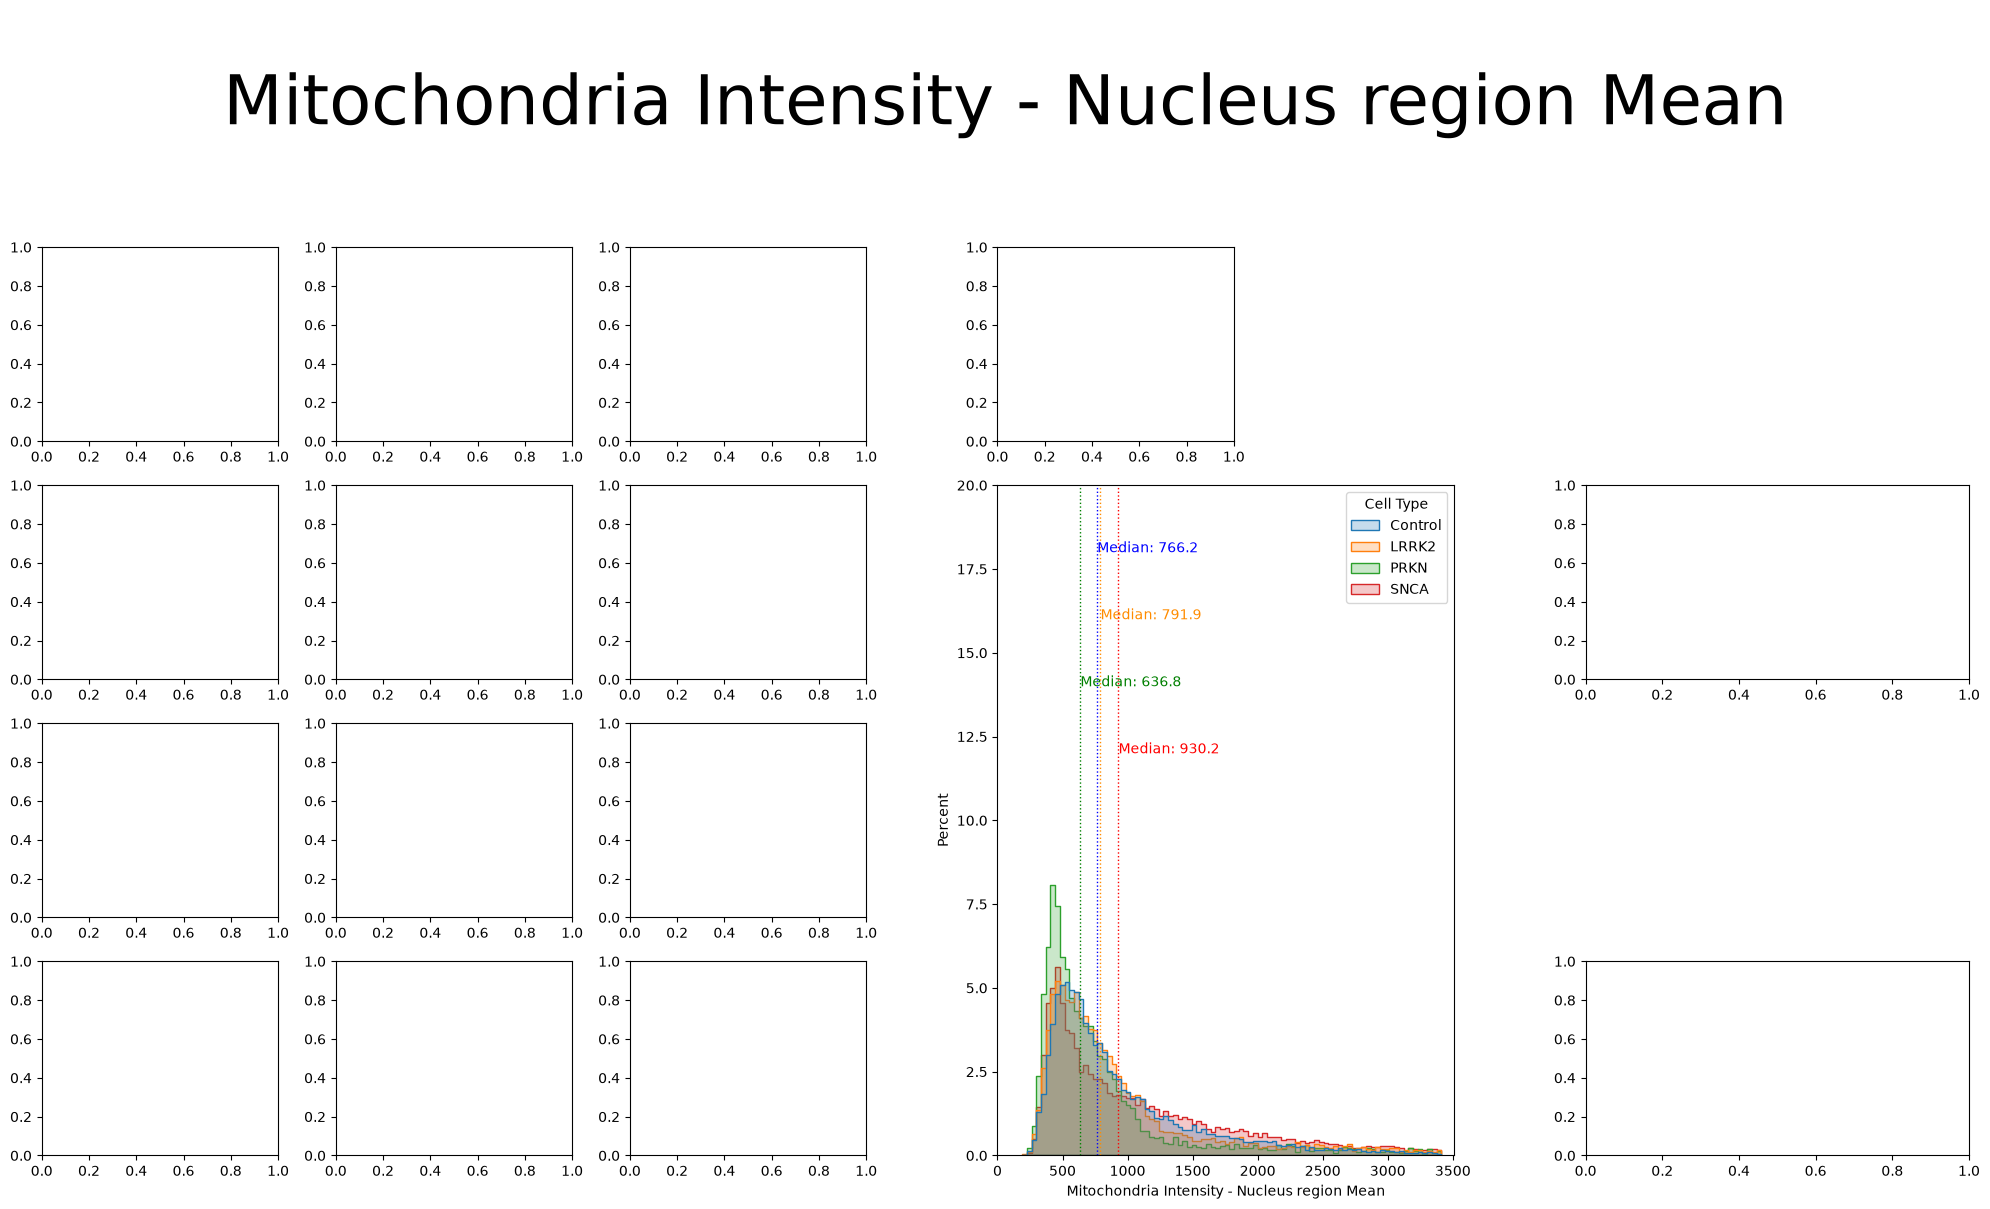

In [35]:
fig

### Make Mini Plots for each cell line

In [36]:
my_list = make_mini_plots(all_variants_df, feature, 'Cellline ID', 'Cell Type', p95)

Control
Control
Control
Control
LRRK2
LRRK2
LRRK2
PRKN
PRKN
PRKN
SNCA
SNCA
SNCA


## Make a Summary Table

In [37]:
# Have a dictionary:
# {"PRKN": {feature: 'Mitochondria Intensity - Middle region Mean', mean: 9000, P1,}}
feature_name = feature

# Get the unique names for categories
variants = pd.unique(mitochondria_df['Cell Type'])
cell_lines = pd.unique(mitochondria_df['Cellline ID'])
summary_dict = {

}

# Go over each each Category, collect the metrics
for variant in variants:
    # Filter based on a feature name
    selected_rows = mitochondria_df[mitochondria_df['Cell Type'] == variant]
    selected_rows = selected_rows[[feature_name]]
    # print(selected_rows)
    metric_dict = calculate_metrics(selected_rows) 
    summary_dict[variant] = metric_dict
    # print(summary_dict)

In [38]:
control_metrics = pd.DataFrame(summary_dict['Control'], index=None)
prkn_metrics = pd.DataFrame(summary_dict['PRKN'])
lrrk2_metrics = pd.DataFrame(summary_dict['LRRK2'])
snca_metrics = pd.DataFrame(summary_dict['SNCA'])
all_metrics = pd.concat([control_metrics, prkn_metrics, lrrk2_metrics, snca_metrics], ignore_index=True)
all_metrics = all_metrics.drop(columns=['feature'])
all_metrics.insert(0, 'Cell Type', ["Control", "PRKN", "LRRK2", "SNCA"])
# all_metrics['Cell Type'] = ["Control", "PRKN", "LRRK2", "SNCA"]

# # Assuming 'summary_df' is your pandas dataframe
table = axes['T'].table(cellText=all_metrics.values,
                        colLabels=all_metrics.columns,
                        loc='center',
                        cellLoc='center')
table.scale(1.15, 2) # Adjust table sizing

table.auto_set_font_size(False)
table.set_fontsize(15)

all_metrics

,Cell Type,P5,P25,P50,P75,P95,P99,Mean
0,Control,387.82,549.07,766.24,1199.36,2513.50,3954.72,1017.43
1,PRKN,351.19,460.07,636.83,948.37,3188.59,5421.43,989.53
2,LRRK2,380.56,548.57,791.89,1392.62,10799.55,20892.94,2017.67
3,SNCA,374.90,536.68,930.23,1705.57,4090.67,6829.18,1395.99


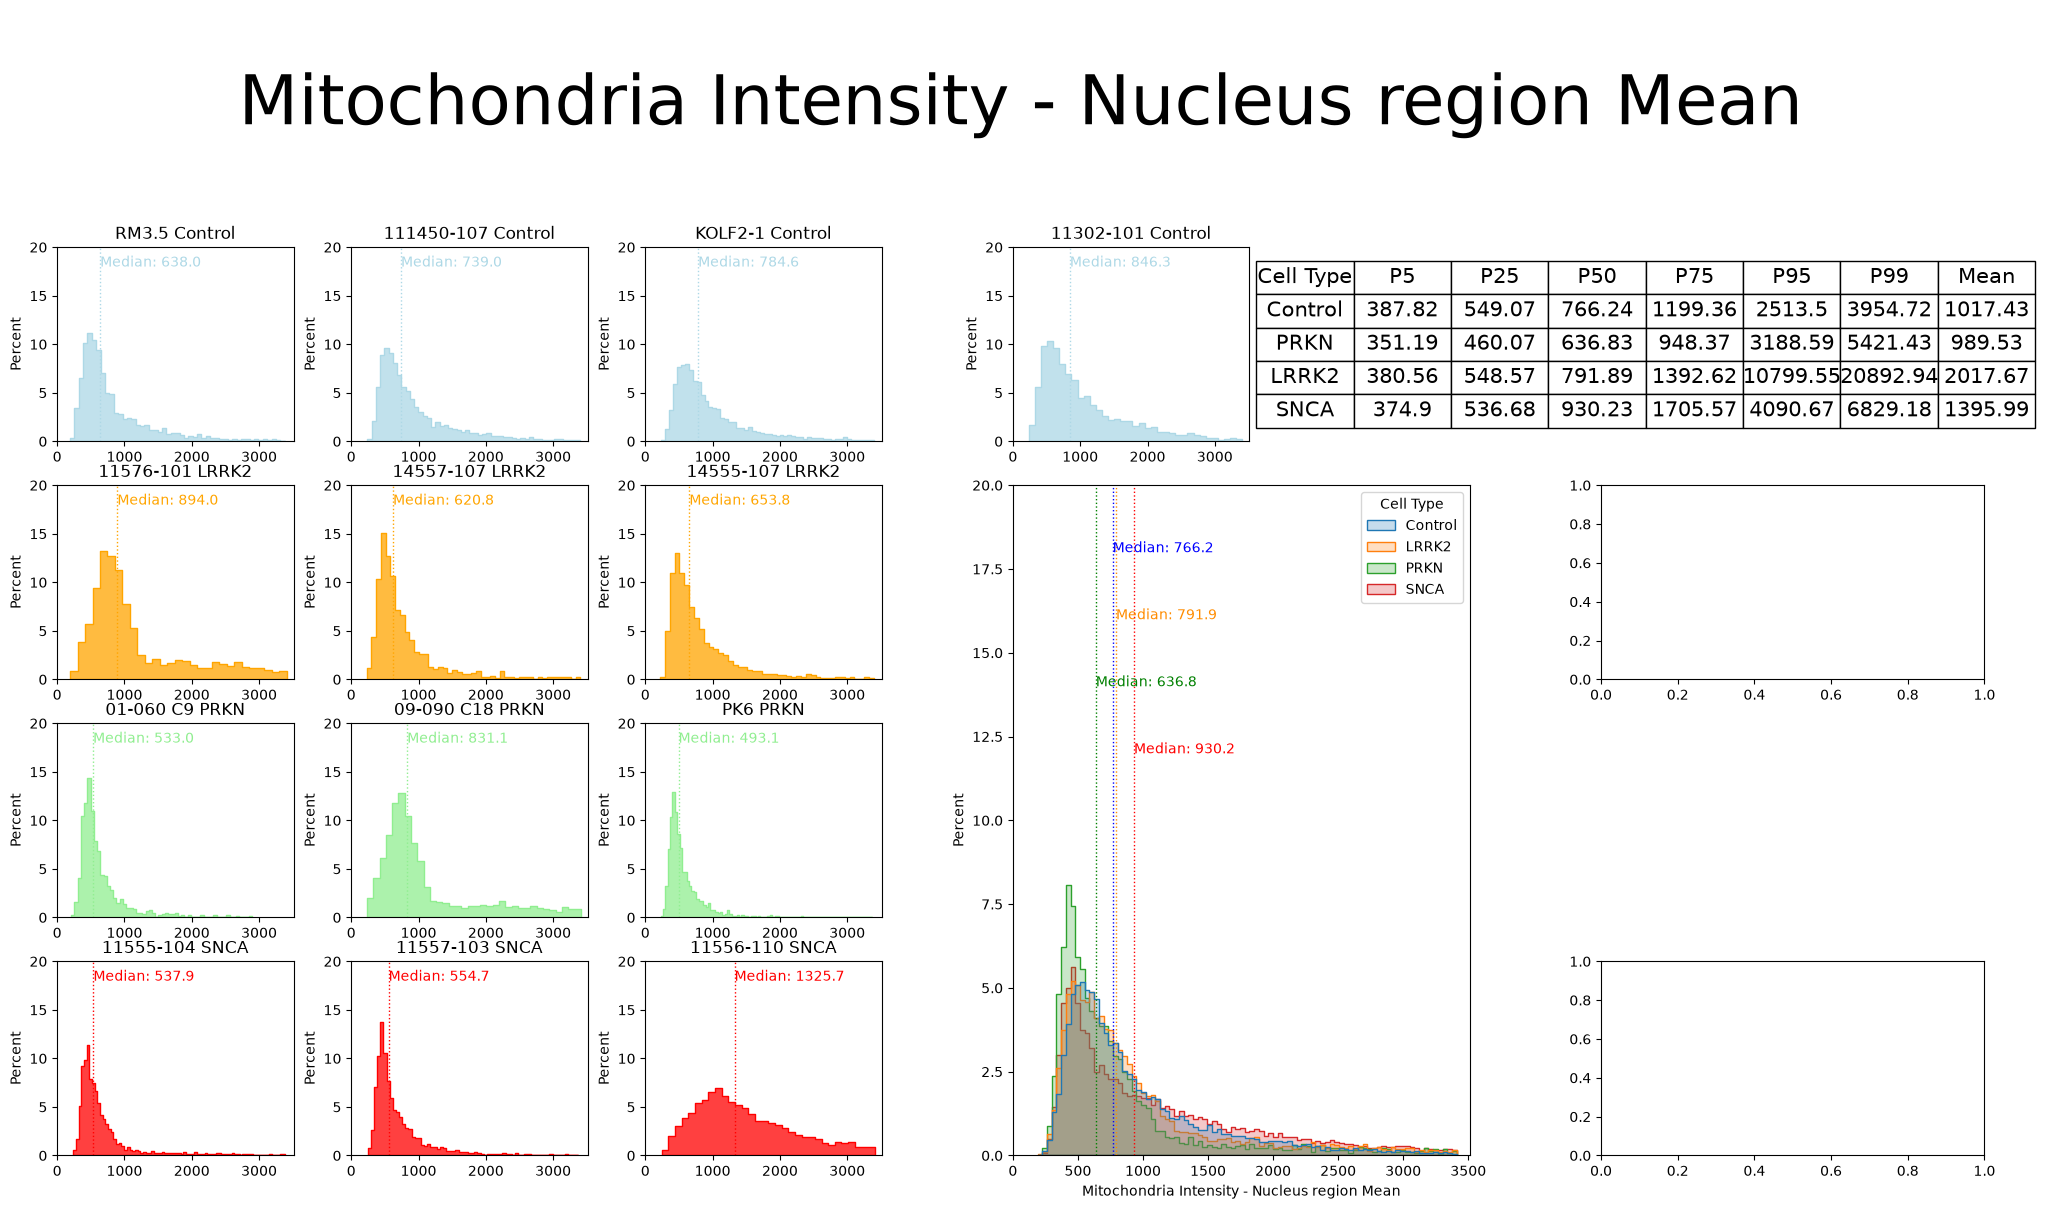

In [39]:
fig

## Create a Box Plots

In [40]:
nucleus_region_mean_box_plot = create_cat_plot(
    all_variants_df,
    feature,
    'Cell Type'
)

/tmp/ipykernel_216530/971238987.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  boxplot = sns.boxplot(


In [41]:
nucleus_region_cv = create_cat_plot(
    all_variants_df,
    secondary_feature,
    'Cell Type'
)

/tmp/ipykernel_216530/971238987.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  boxplot = sns.boxplot(


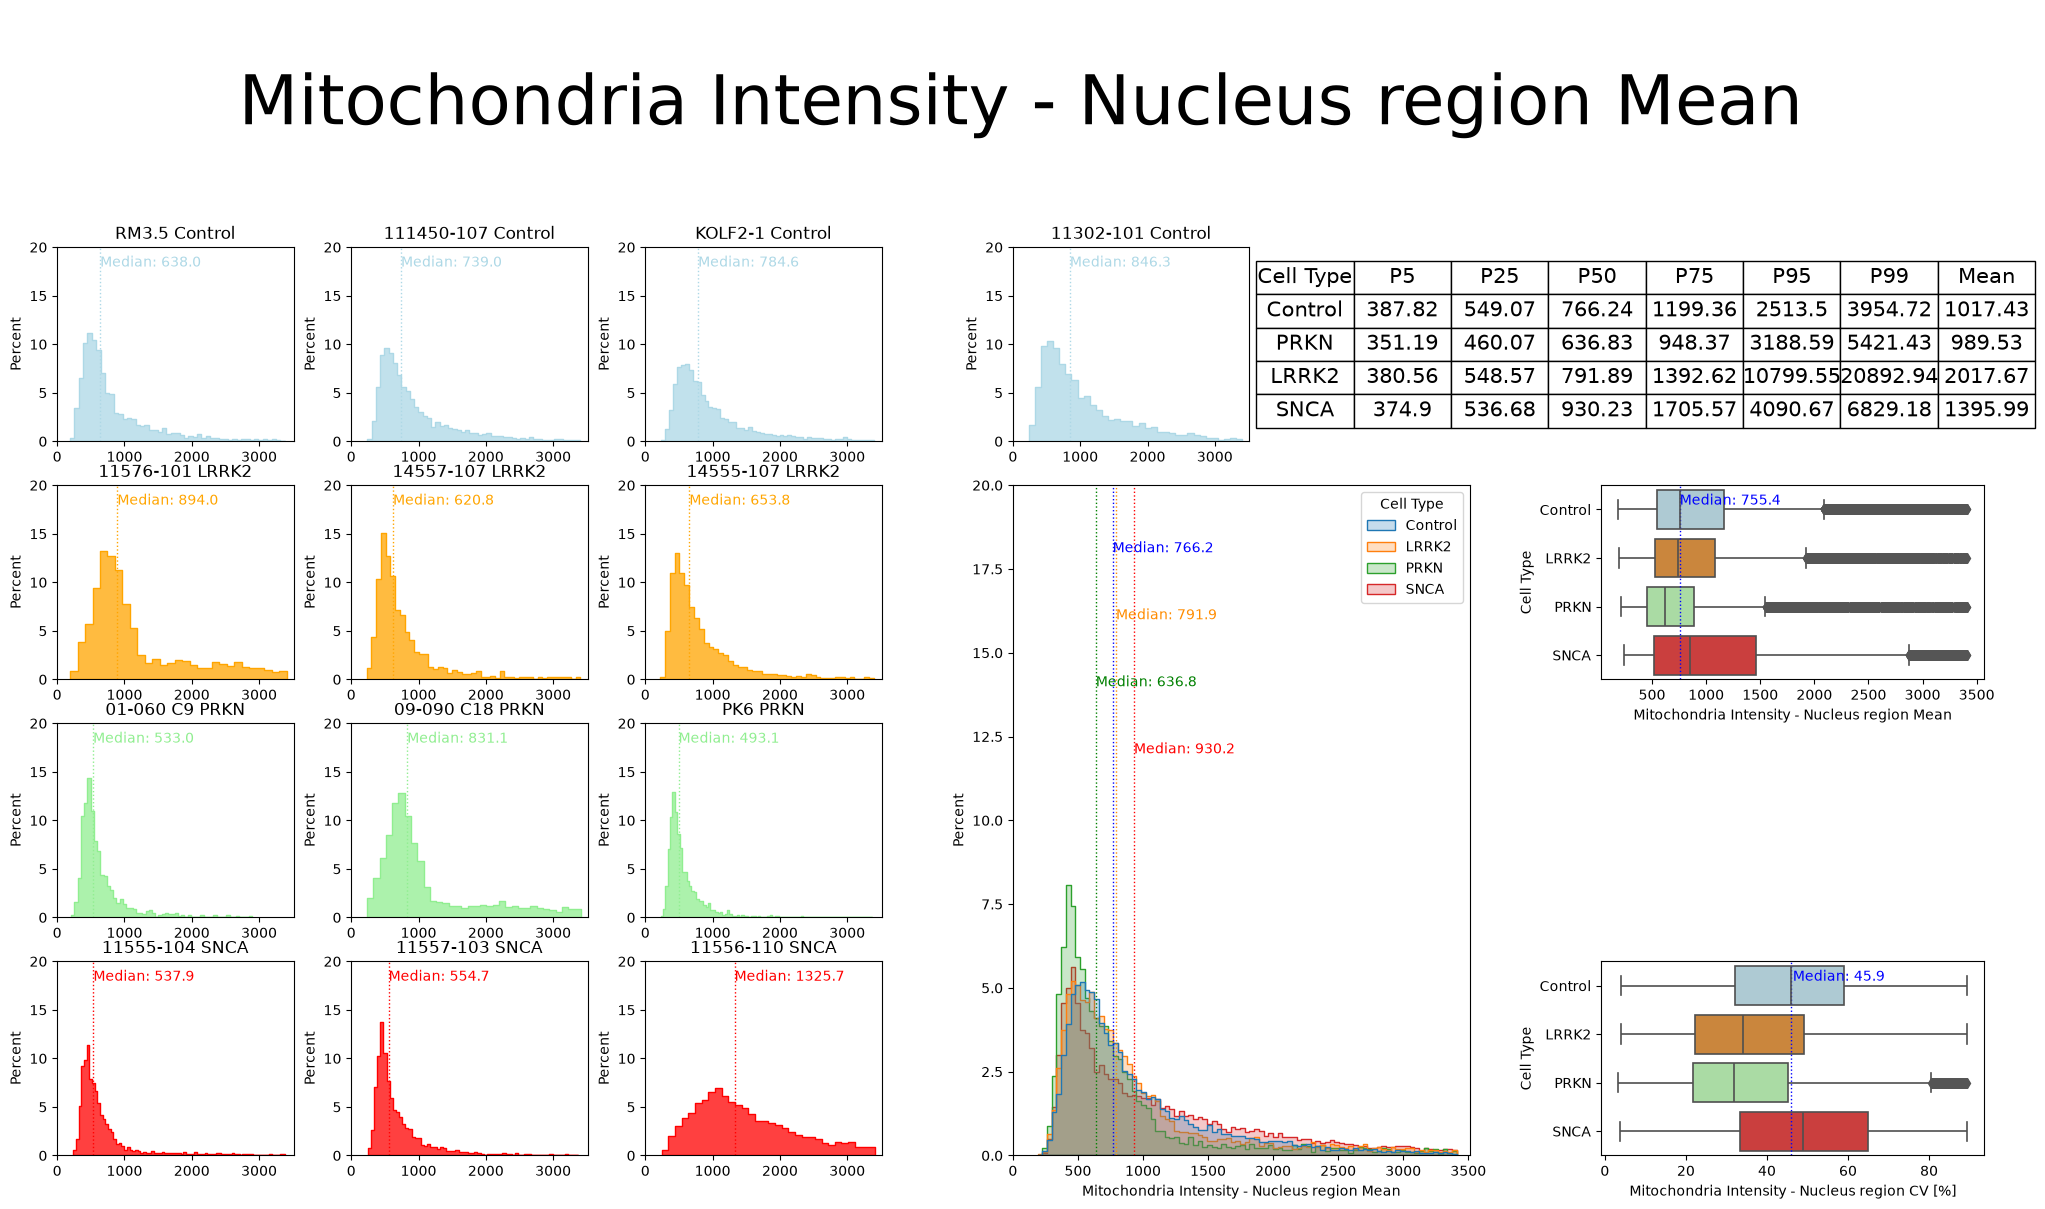

In [42]:
fig

In [43]:
fig.savefig(f"{feature}.png")

### Create a Scatter Plot to see clusters

<Axes: xlabel='Mitochondria Intensity - Nucleus region Mean', ylabel='Mitochondria Intensity - Nucleus region CV [%]'>

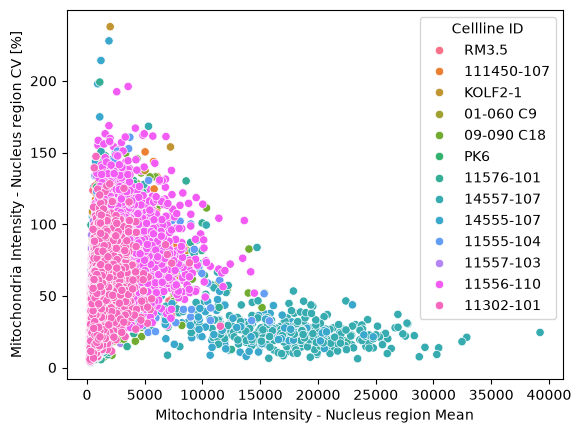

In [44]:


sns.scatterplot(
    data=mitochondria_df,
    x=feature,
    y=secondary_feature,
    hue=category,
)